In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import joblib

In [2]:
train_df = pd.read_csv("../data/processed/train_smote.csv")
test_df = pd.read_csv("../data/processed/test_data.csv")
print(train_df.shape)
print(test_df.shape)

(1582354, 48)
(200000, 48)


In [3]:
X_train = train_df.drop("fraud_bool", axis=1)
X_test = test_df.drop("fraud_bool", axis=1)
y_test = test_df["fraud_bool"]

In [4]:
#train isolation forest
iso = IsolationForest(
    n_estimators=200,
    contamination=0.011,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.011
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [5]:
pred = iso.predict(X_test)
y_pred = np.where(pred == -1, 1, 0)

In [6]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.967915
Precision: 0.004704775346977182
Recall   : 0.009066183136899365
F1 Score : 0.006194827319188478


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98    197794
           1       0.00      0.01      0.01      2206

    accuracy                           0.97    200000
   macro avg       0.50      0.49      0.49    200000
weighted avg       0.98      0.97      0.97    200000



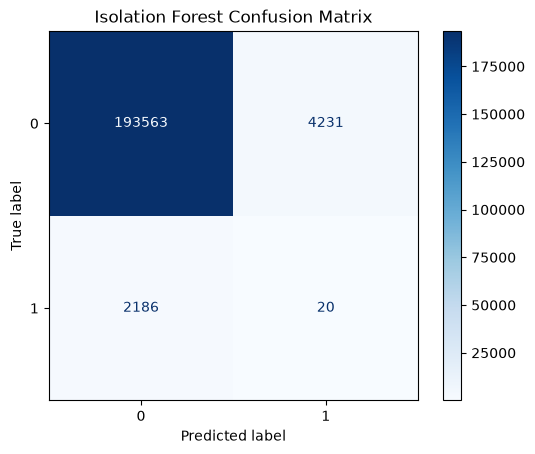

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Isolation Forest Confusion Matrix")
plt.show()

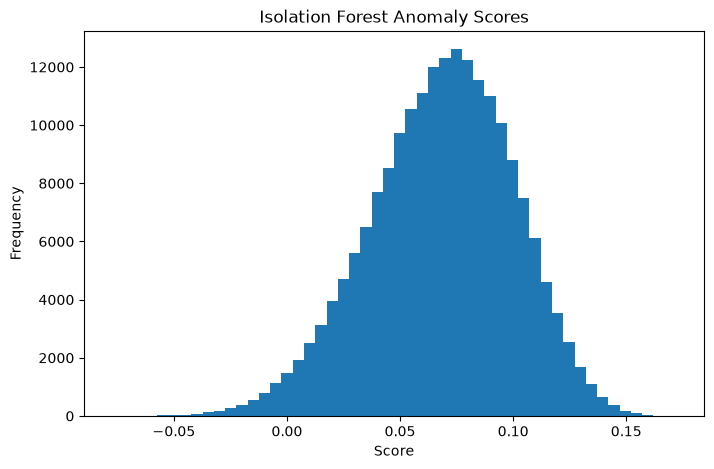

In [9]:
#anamoly score
scores = iso.decision_function(X_test)
plt.figure(figsize=(8,5))
plt.hist(scores, bins=50)
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [10]:
joblib.dump(iso,"../models/isolation_forest.pkl")
print("Isolation Forest model saved.")

Isolation Forest model saved.


## Summary

• Loaded the SMOTE-balanced training dataset and original test dataset.
• Trained an Isolation Forest model for anomaly detection.
• Predicted anomalous transactions on the test dataset.
• Converted anomaly labels to fraud/non-fraud labels.
• Evaluated the model using Accuracy, Precision, Recall, and F1-score.
• Generated a Classification Report and Confusion Matrix.
• Visualized anomaly score distribution.
• Saved the trained Isolation Forest model for future use.